# Bài Tập Qua Tết 
## Thử trên tập data MNIST và cat and dog
    - deadline 6/03/2026
    - Nhưng phải làm theo cấu trúc file lab
    - Dùng PyTorh

# Tập data MNIST 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [5]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=1000, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)
images, labels = next(iter(train_loader))
images_test, labels_test = next(iter(test_loader))

print(f"Số lượng ảnh train: {len(train_dataset)}")
print(f"Số lượng ảnh test: {len(test_dataset)}")

Số lượng ảnh train: 60000
Số lượng ảnh test: 10000


In [19]:
# Xây ANN bằng PyTorch
class ANN_MNIST(nn.Module):
    def __init__(self):
        super(ANN_MNIST, self).__init__()
        self.layer1 = nn.Linear(784, 128)  # Đầu vào 784, ẩn 128
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 10)   # Đầu ra 10 lớp (0-9)

    def forward(self, x):
        x = x.view(-1, 784) # Duỗi ảnh 2D thành 1D
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

# Khởi tạo mô hình
model = ANN_MNIST()
# Định nghĩa mất mát và tối ưu hóa
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.01)
# Huấn luyện
loss_history = []
acc_history = []
epochs = 80
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    
    # Lưu lại lịch sử để vẽ
    loss_history.append(loss.item())
    with torch.no_grad():
        scores, predicted = torch.max(outputs.data, 1)
        acc = (predicted.eq(labels).sum() / labels.size(0)).item()
        acc_history.append(acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {acc*100:.2f}%")

save_path = 'ANN_MNIST.pth'
torch.save(model.state_dict(), save_path)

Epoch [10/80], Loss: 1.6706, Acc: 49.70%
Epoch [20/80], Loss: 0.7470, Acc: 77.90%
Epoch [30/80], Loss: 0.4632, Acc: 86.30%
Epoch [40/80], Loss: 0.3377, Acc: 90.60%
Epoch [50/80], Loss: 0.2567, Acc: 93.10%
Epoch [60/80], Loss: 0.1948, Acc: 95.80%
Epoch [70/80], Loss: 0.1475, Acc: 96.70%
Epoch [80/80], Loss: 0.1107, Acc: 98.20%


In [20]:
# Kiểm tra
model.eval()
with torch.no_grad():
    y_pred = model(images)
    max_values, predicted_labels = torch.max(y_pred.data, 1)
    accuracy = (predicted_labels.eq(labels).sum() / labels.size(0)).item()
    print(f"Độ chính xác trên tập test: {accuracy*100:.2f}%")

Độ chính xác trên tập test: 98.30%


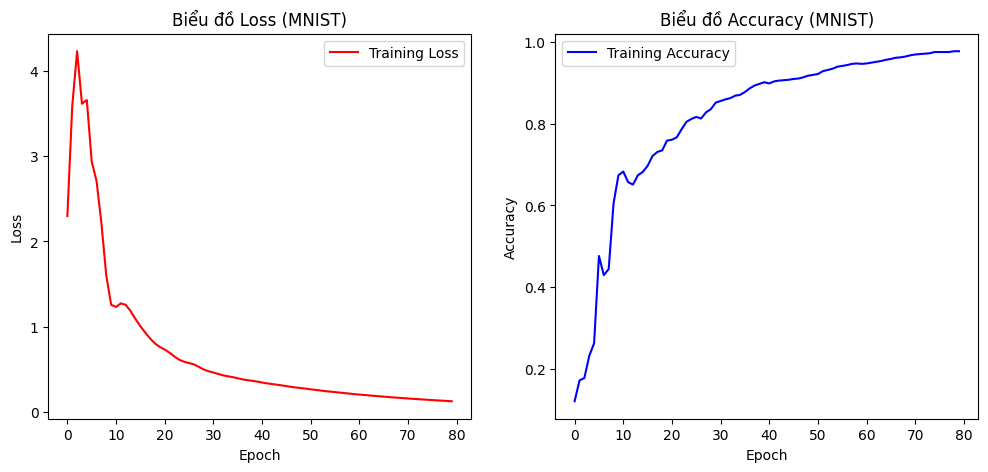

In [18]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='red', label='Training Loss')
plt.title('Biểu đồ Loss (MNIST)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(acc_history, color='blue', label='Training Accuracy')
plt.title('Biểu đồ Accuracy (MNIST)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Tập cat and dog

In [66]:
import numpy as np
import torch
import os
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_path = 'Cat_and_Dog'
img_size = 64 
train_preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.Grayscale(num_output_channels=1), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) 
])

val_preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# 3. LOAD DỮ LIỆU
train_raw = datasets.ImageFolder(os.path.join(data_path, 'training_set'), transform=train_preprocess)
val_raw = datasets.ImageFolder(os.path.join(data_path, 'test_set'), transform=val_preprocess)

train_loader = DataLoader(train_raw, batch_size=64, shuffle=True)
val_loader = DataLoader(val_raw, batch_size=64, shuffle=False)

In [ ]:
class ANN_CAT_DOG(nn.Module):
    def __init__(self):
        super(ANN_CAT_DOG, self).__init__()
        
        # Đầu vào giờ chỉ còn 4096 thay vì 49152 (Giảm cực mạnh khối lượng tính toán)
        self.model = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.model(x)

model = ANN_CAT_DOG().to(device)

# 5. TỐI ƯU HÓA
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.0005) # LR nhỏ để hội tụ từ từ

# 6. HUẤN LUYỆN
epochs = 100
for epoch in range(epochs):
    model.train()
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    if (epoch + 1) % 10 == 0:
        train_acc = 100 * correct_train / total_train
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {train_acc:.2f}%")

save_path = 'cat_and_dog_model.pth'
torch.save(model.state_dict(), save_path)

Epoch [5/250], Loss: 0.6437, Train Acc: 62.55%
Epoch [10/250], Loss: 0.6302, Train Acc: 63.18%
Epoch [15/250], Loss: 0.6108, Train Acc: 66.16%
Epoch [20/250], Loss: 0.6054, Train Acc: 67.05%
Epoch [25/250], Loss: 0.5893, Train Acc: 68.38%
Epoch [30/250], Loss: 0.5853, Train Acc: 68.36%
Epoch [35/250], Loss: 0.5764, Train Acc: 69.69%
Epoch [40/250], Loss: 0.5609, Train Acc: 70.58%
Epoch [45/250], Loss: 0.5558, Train Acc: 70.17%
Epoch [50/250], Loss: 0.5488, Train Acc: 71.79%
Epoch [55/250], Loss: 0.5369, Train Acc: 72.64%
Epoch [60/250], Loss: 0.5271, Train Acc: 73.24%
Epoch [65/250], Loss: 0.5173, Train Acc: 74.16%
Epoch [70/250], Loss: 0.4998, Train Acc: 75.51%
Epoch [75/250], Loss: 0.5014, Train Acc: 74.42%
Epoch [80/250], Loss: 0.4871, Train Acc: 75.69%
Epoch [85/250], Loss: 0.4851, Train Acc: 75.51%
Epoch [90/250], Loss: 0.4639, Train Acc: 77.76%
Epoch [95/250], Loss: 0.4653, Train Acc: 77.55%
Epoch [100/250], Loss: 0.4556, Train Acc: 77.98%
Epoch [105/250], Loss: 0.4410, Train Acc

In [84]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader: 
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Độ chính xác trên tập kiểm tra: {accuracy*100:.2f}%")

Độ chính xác trên tập kiểm tra: 69.35%


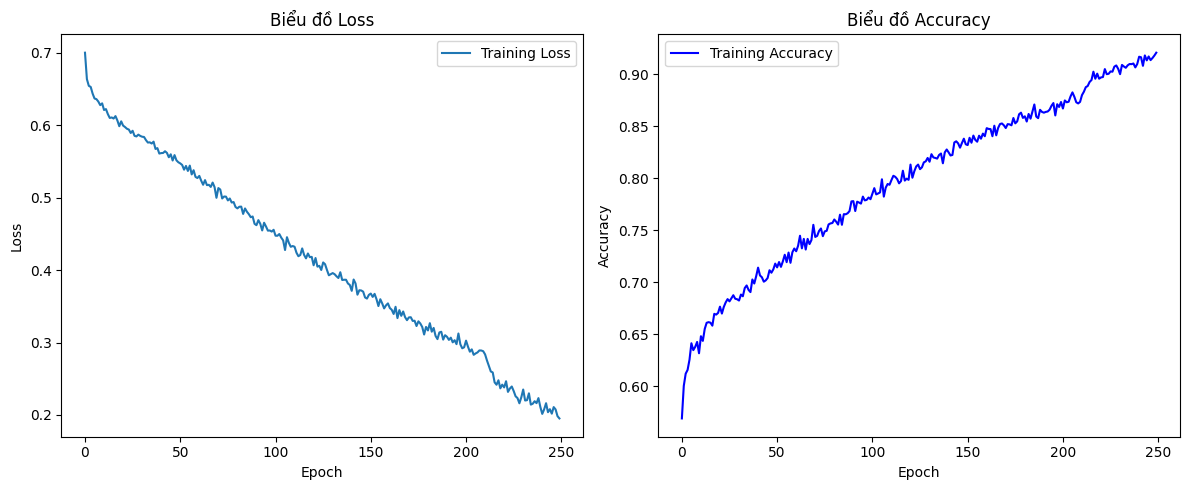

In [85]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Training Loss')
plt.title('Biểu đồ Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_history, color='blue', label='Training Accuracy')
plt.title('Biểu đồ Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()